In [1]:
import pandas as pd
import wandb
api = wandb.Api()

# Project is specified by <entity/project-name>
runs = api.runs("skqorekdls-kwangwoon-university/mlops-cifar100")

summary_list, config_list, name_list = [], [], []
for run in runs:
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files
    summary_list.append(run.summary._json_dict)

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k,v in run.config.items()
          if not k.startswith('_')})

    # .name is the human-readable name of the run.
    name_list.append(run.name)

runs_df = pd.DataFrame({
    "summary": summary_list,
    "config": config_list,
    "name": name_list
    })

runs_df.to_csv("project.csv")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\dochi\_netrc.


최종 선택된 run 개수: 7
                                            run_name  best_val_acc  \
0               baseline_resnet18_adamw_lr1e-3_bs128        0.8060   
1                        resnet18_adamw_lr3e-4_bs128        0.8376   
2                          resnet18_sgd_lr1e-2_bs128        0.8376   
3                         resnet18_adamw_lr1e-3_bs64        0.7908   
4              resnet18_adamw_lr1e-3_bs128_strongaug        0.8046   
5          efficientnetb0_adamw_lr1e-3_bs64_basicaug        0.8456   
6  FINAL_efficientnetb0_adamw_lr1e-3_bs64_basicau...        0.8410   

   final_test_acc  
0          0.7961  
1          0.8310  
2          0.8292  
3          0.7934  
4          0.7981  
5          0.8463  
6          0.8408  


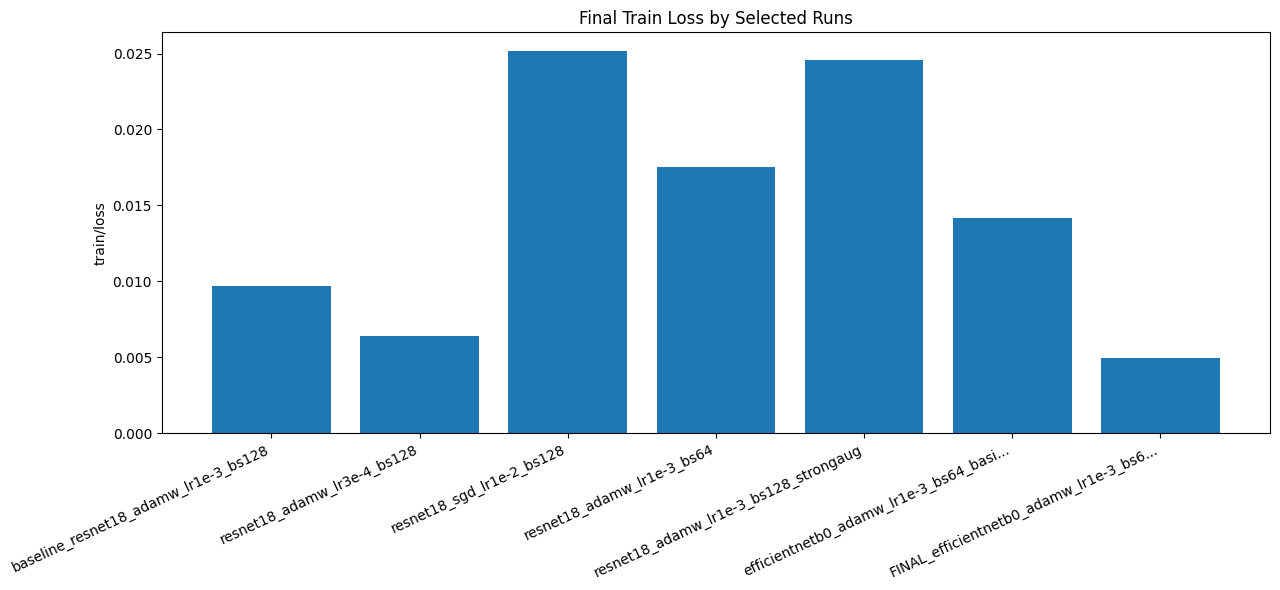

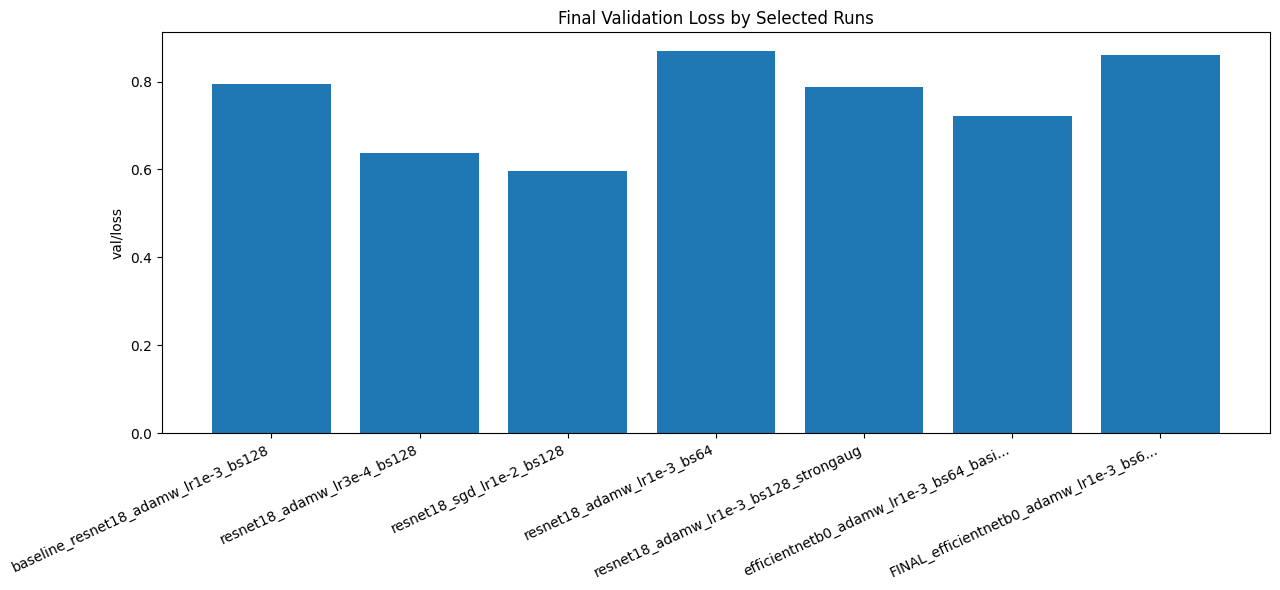

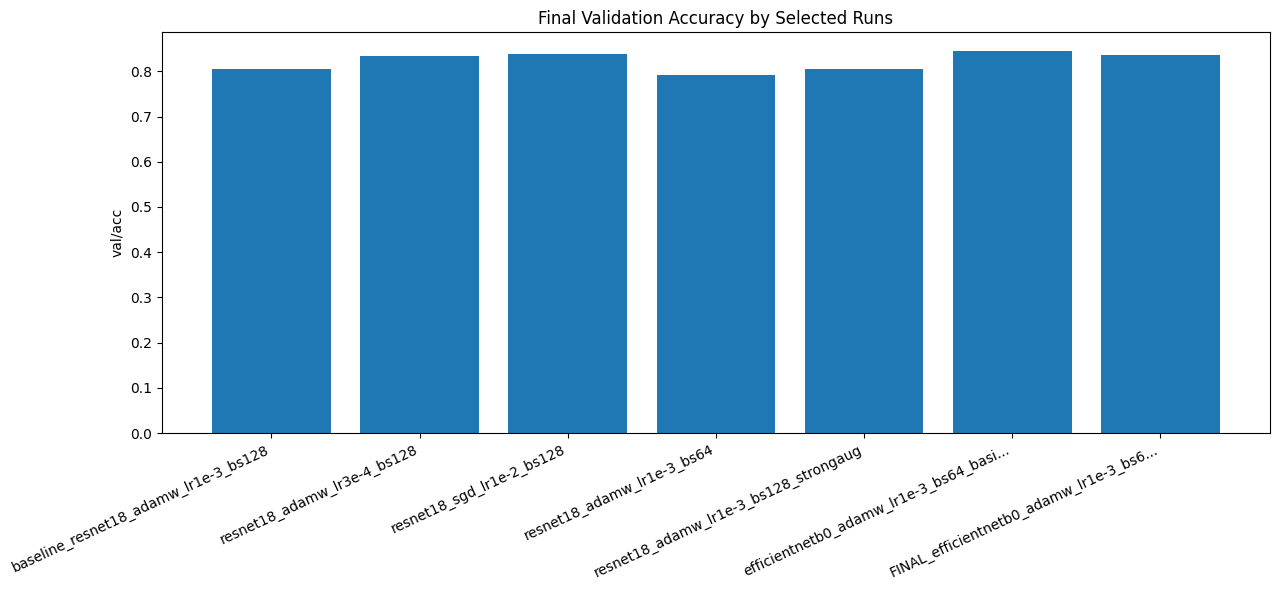

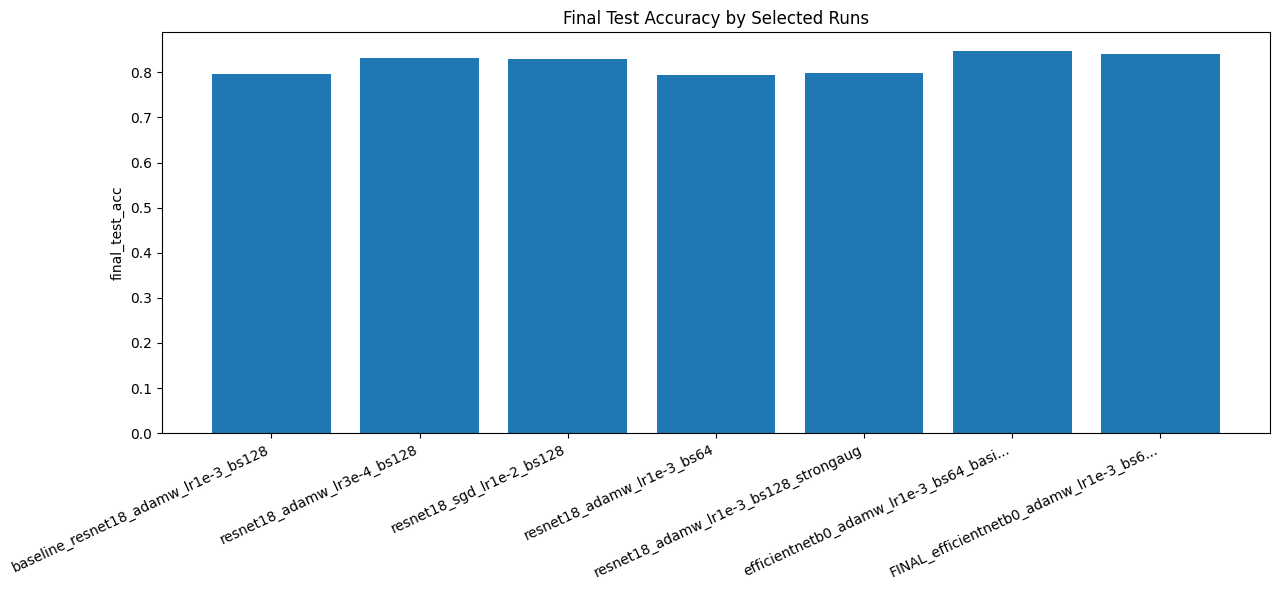

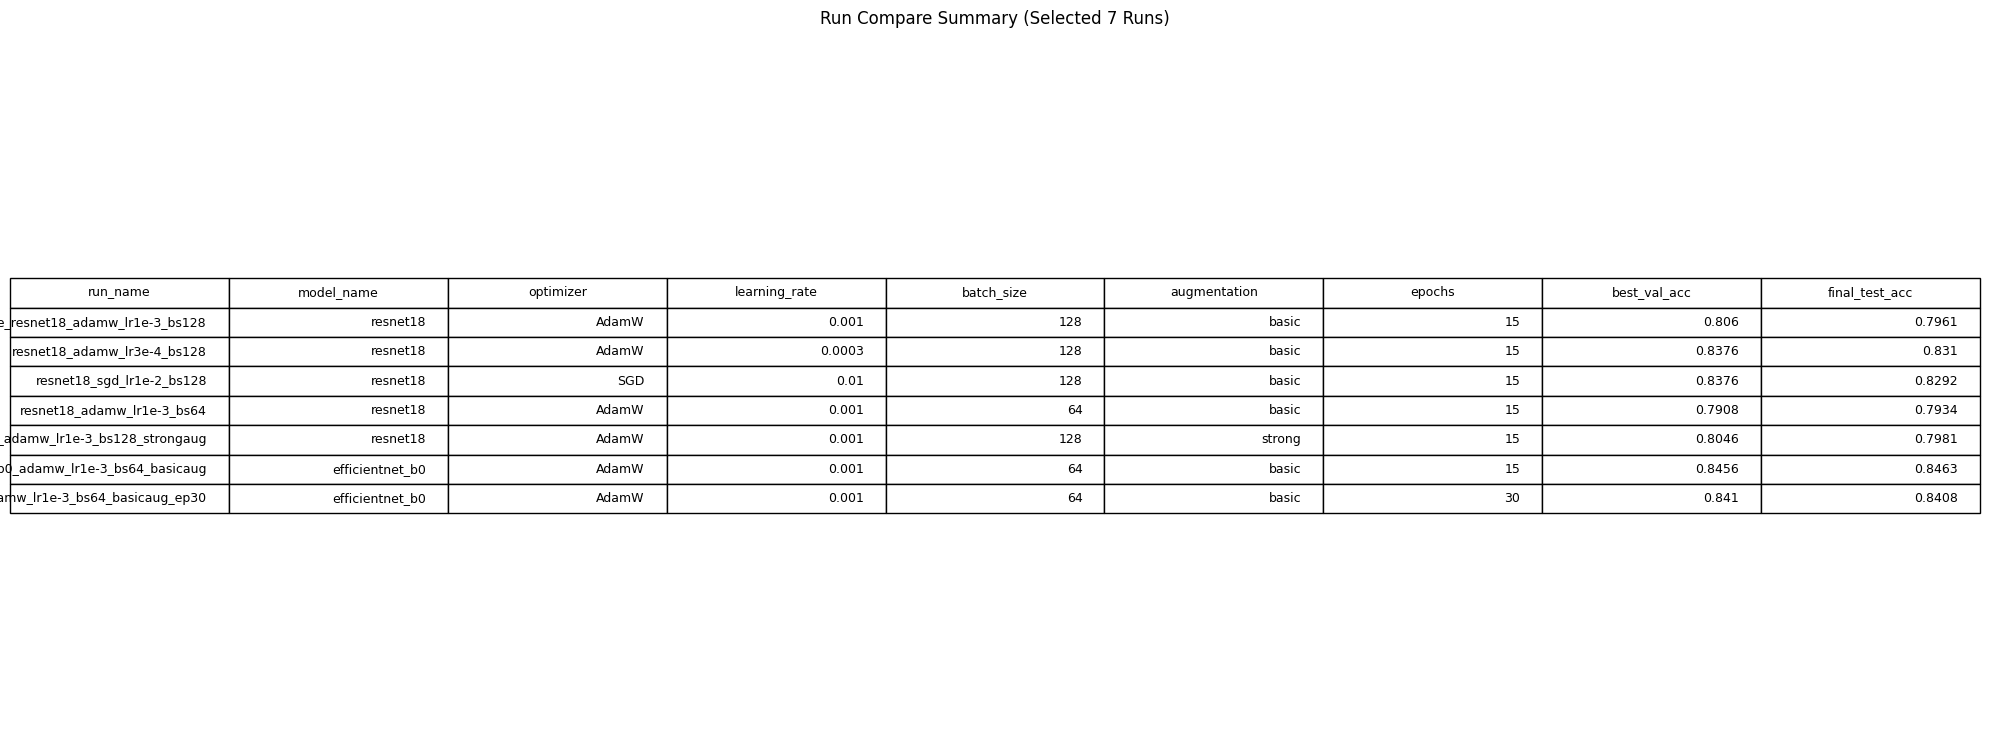


저장 완료 폴더: C:\Users\dochi\Desktop\wandb_hw\project_report_figures_selected
- parsed_run_summary_selected.csv
- run_compare_table_selected.png
- test_acc_selected.png
- train_loss_selected.png
- val_acc_selected.png
- val_loss_selected.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
from pathlib import Path

# =========================
# 1. CSV 로드
# =========================
csv_path = r"C:\Users\dochi\Desktop\wandb_hw\project.csv"
raw_df = pd.read_csv(csv_path)

def safe_parse(x):
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return {}

raw_df["summary_dict"] = raw_df["summary"].apply(safe_parse)
raw_df["config_dict"] = raw_df["config"].apply(safe_parse)

summary_df = pd.json_normalize(raw_df["summary_dict"]).add_prefix("sum_")
config_df = pd.json_normalize(raw_df["config_dict"]).add_prefix("cfg_")

df = pd.concat(
    [
        raw_df[["name"]].rename(columns={"name": "run_name"}),
        config_df,
        summary_df
    ],
    axis=1
)

# augmentation 보정
if "cfg_augmentation" not in df.columns:
    df["cfg_augmentation"] = "basic"
else:
    df["cfg_augmentation"] = df["cfg_augmentation"].fillna("basic")

# =========================
# 2. 필요한 컬럼 정리
# =========================
clean_df = pd.DataFrame()
clean_df["run_name"] = df["run_name"].astype(str).str.strip()

if "cfg_model_name" in df.columns:
    clean_df["model_name"] = df["cfg_model_name"]
if "cfg_optimizer" in df.columns:
    clean_df["optimizer"] = df["cfg_optimizer"]
if "cfg_learning_rate" in df.columns:
    clean_df["learning_rate"] = df["cfg_learning_rate"]
if "cfg_batch_size" in df.columns:
    clean_df["batch_size"] = df["cfg_batch_size"]
if "cfg_augmentation" in df.columns:
    clean_df["augmentation"] = df["cfg_augmentation"]
if "cfg_epochs" in df.columns:
    clean_df["epochs"] = df["cfg_epochs"]

if "sum_best_epoch" in df.columns:
    clean_df["best_epoch"] = df["sum_best_epoch"]
if "sum_best_val_acc" in df.columns:
    clean_df["best_val_acc"] = pd.to_numeric(df["sum_best_val_acc"], errors="coerce")
if "sum_final_test_acc" in df.columns:
    clean_df["final_test_acc"] = pd.to_numeric(df["sum_final_test_acc"], errors="coerce")
if "sum_final_test_loss" in df.columns:
    clean_df["final_test_loss"] = pd.to_numeric(df["sum_final_test_loss"], errors="coerce")
if "sum_train/loss" in df.columns:
    clean_df["train/loss"] = pd.to_numeric(df["sum_train/loss"], errors="coerce")
if "sum_val/loss" in df.columns:
    clean_df["val/loss"] = pd.to_numeric(df["sum_val/loss"], errors="coerce")
if "sum_train/acc" in df.columns:
    clean_df["train/acc"] = pd.to_numeric(df["sum_train/acc"], errors="coerce")
if "sum_val/acc" in df.columns:
    clean_df["val/acc"] = pd.to_numeric(df["sum_val/acc"], errors="coerce")

# =========================
# 3. 원하는 7개 run만 선택
# =========================
target_runs = [
    "baseline_resnet18_adamw_lr1e-3_bs128",
    "resnet18_adamw_lr3e-4_bs128",
    "resnet18_sgd_lr1e-2_bs128",
    "resnet18_adamw_lr1e-3_bs64",
    "resnet18_adamw_lr1e-3_bs128_strongaug",
    "efficientnetb0_adamw_lr1e-3_bs64_basicaug",
    "FINAL_efficientnetb0_adamw_lr1e-3_bs64_basicaug_ep30",
]

clean_df = clean_df[clean_df["run_name"].isin(target_runs)].copy()

# =========================
# 4. 같은 이름 중복 제거
#    우선순위:
#    final_test_acc 높은 것 > best_val_acc 높은 것 > val/acc 높은 것
# =========================
for col in ["final_test_acc", "best_val_acc", "val/acc"]:
    if col not in clean_df.columns:
        clean_df[col] = np.nan

clean_df = clean_df.sort_values(
    by=["run_name", "final_test_acc", "best_val_acc", "val/acc"],
    ascending=[True, False, False, False]
)

clean_df = clean_df.drop_duplicates(subset="run_name", keep="first").copy()

# target_runs 순서대로 다시 정렬
clean_df["run_name"] = pd.Categorical(clean_df["run_name"], categories=target_runs, ordered=True)
clean_df = clean_df.sort_values("run_name").reset_index(drop=True)

# 라벨
def shorten_name(name, max_len=40):
    name = str(name)
    return name if len(name) <= max_len else name[:max_len-3] + "..."

clean_df["label"] = clean_df["run_name"].astype(str).apply(shorten_name)

# 저장 폴더
out_dir = Path(csv_path).parent / "project_report_figures_selected"
out_dir.mkdir(exist_ok=True)

# CSV 저장
clean_df.to_csv(out_dir / "parsed_run_summary_selected.csv", index=False)

print("최종 선택된 run 개수:", len(clean_df))
print(clean_df[["run_name", "best_val_acc", "final_test_acc"]])

# =========================
# 5. 그래프 함수
# =========================
def save_bar_plot(dataframe, x_col, y_col, title, ylabel, filename, rotate=25):
    plt.figure(figsize=(13, 6))
    x = np.arange(len(dataframe))
    y = dataframe[y_col].values

    plt.bar(x, y)
    plt.xticks(x, dataframe[x_col].values, rotation=rotate, ha="right")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(out_dir / filename, dpi=220, bbox_inches="tight")
    plt.show()

# =========================
# 6. 그래프 저장
# =========================
if "train/loss" in clean_df.columns:
    save_bar_plot(clean_df, "label", "train/loss",
                  "Final Train Loss by Selected Runs",
                  "train/loss", "train_loss_selected.png")

if "val/loss" in clean_df.columns:
    save_bar_plot(clean_df, "label", "val/loss",
                  "Final Validation Loss by Selected Runs",
                  "val/loss", "val_loss_selected.png")

if "val/acc" in clean_df.columns:
    save_bar_plot(clean_df, "label", "val/acc",
                  "Final Validation Accuracy by Selected Runs",
                  "val/acc", "val_acc_selected.png")

if "final_test_acc" in clean_df.columns:
    save_bar_plot(clean_df, "label", "final_test_acc",
                  "Final Test Accuracy by Selected Runs",
                  "final_test_acc", "test_acc_selected.png")

# =========================
# 7. run compare 표 저장
# =========================
table_cols = [c for c in [
    "run_name", "model_name", "optimizer", "learning_rate",
    "batch_size", "augmentation", "epochs",
    "best_val_acc", "final_test_acc"
] if c in clean_df.columns]

table_df = clean_df[table_cols].copy()

fig, ax = plt.subplots(figsize=(20, 0.8 * len(table_df) + 2))
ax.axis("off")
table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.title("Run Compare Summary (Selected 7 Runs)", pad=20)
plt.tight_layout()
plt.savefig(out_dir / "run_compare_table_selected.png", dpi=220, bbox_inches="tight")
plt.show()

print(f"\n저장 완료 폴더: {out_dir}")
for p in sorted(out_dir.glob("*")):
    print("-", p.name)                                                                                                                                                                                                                                                                                                                                                                                                                                  